In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [36]:
df = pd.read_csv(r"D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\advertising.csv")
df 

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [37]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


(200, 4)

In [38]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [39]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


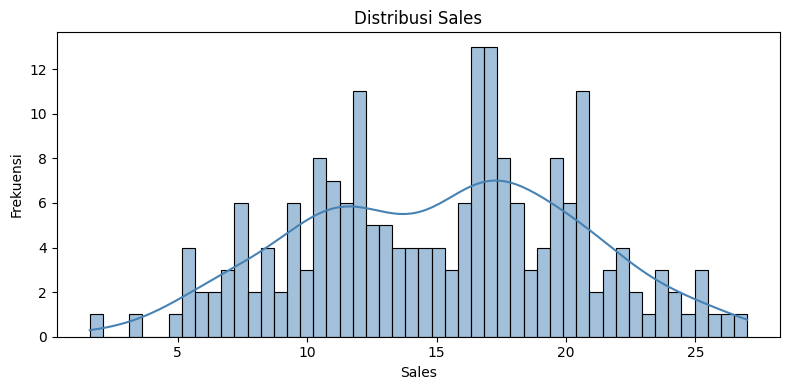

In [40]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Sales')
plt.xlabel('Sales')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

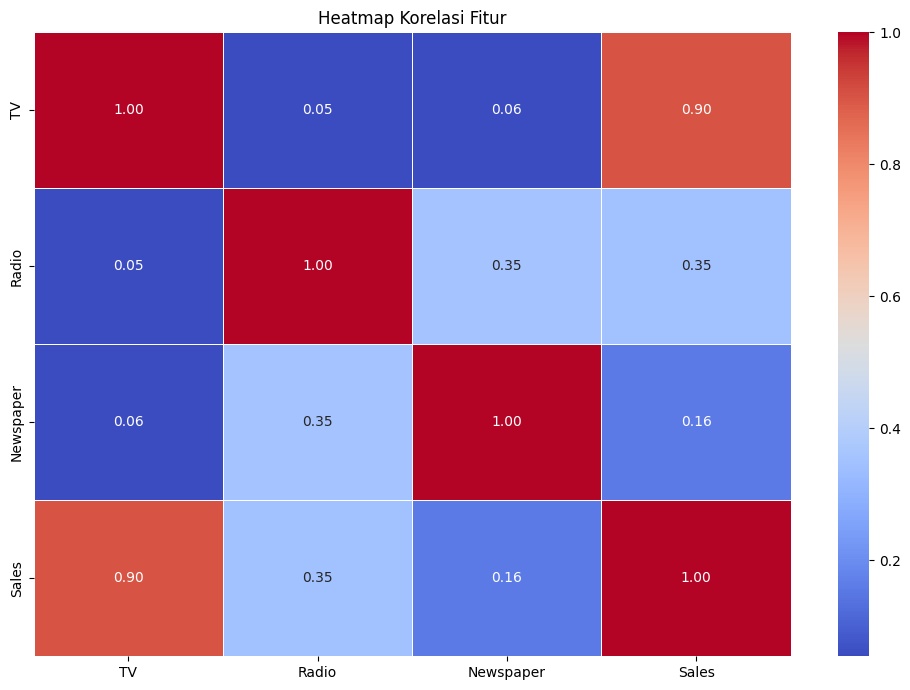

In [41]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

In [42]:
X = df.drop(columns=['Sales'])
y = df['Sales']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\nUkuran data train : {X_train.shape}")
print(f"Ukuran data test  : {X_test.shape}")


Ukuran data train : (160, 3)
Ukuran data test  : (40, 3)


In [44]:
rf_model = RandomForestRegressor(
    n_estimators=200,     
    max_features='sqrt',  
    max_depth=20,         
    min_samples_leaf=4,   
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)


def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print(f"MSE     : {mse_rf}")
print(f"R2      : {r2_rf}")
print(f"MAPE    : {mape_rf}") 

MSE     : 4.111202922527191
R2      : 0.8669560979212005
MAPE    : 15.50289443643237


In [45]:
print("Interpretasi ")
if r2_rf >= 0.9:
    interpretasi = "Sangat baik"
elif r2_rf >= 0.75:
    interpretasi = "Baik"
elif r2_rf >= 0.5:
    interpretasi = "Cukup"
else:
    interpretasi = "Perlu perbaikan"
print(f"R² Score {r2_rf:.4f} → {interpretasi}")
print(f"Model rata-rata meleset sebesar {mape_rf:.2f}% dari nilai aktual (MAPE)")

Interpretasi 
R² Score 0.8670 → Baik
Model rata-rata meleset sebesar 15.50% dari nilai aktual (MAPE)


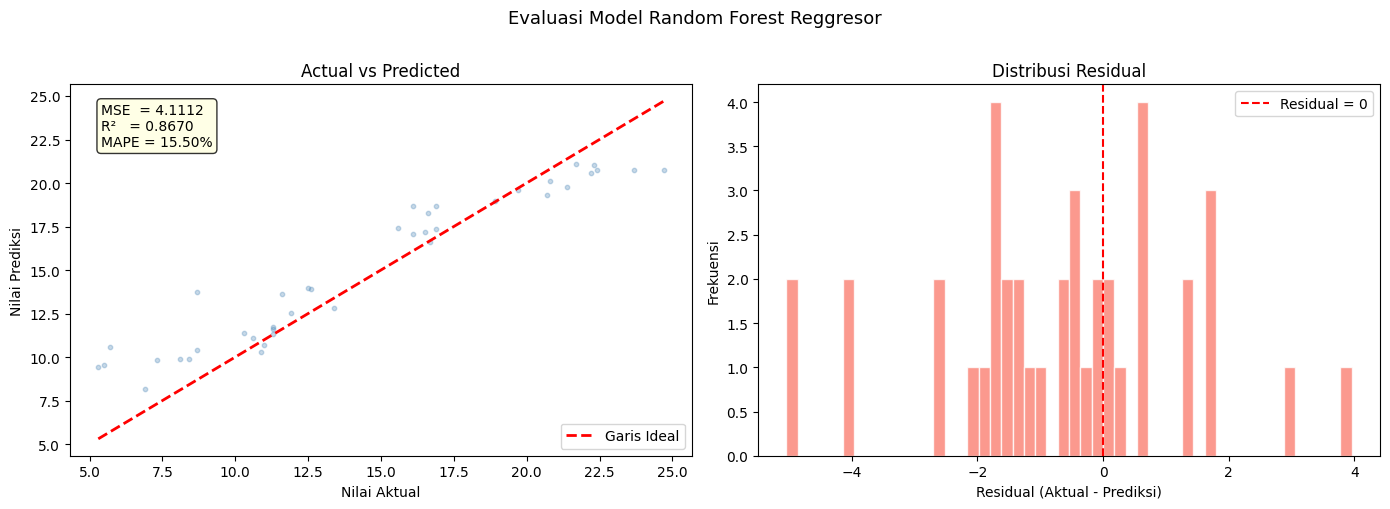

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Garis Ideal'
)
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
# Tambahkan teks metrik
metrik_text = f"MSE  = {mse_rf:.4f}\nR²   = {r2_rf:.4f}\nMAPE = {mape_rf:.2f}%"
axes[0].text(
    0.05, 0.95, metrik_text,
    transform=axes[0].transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
 
# Plot 2: Distribusi Residual
residuals = y_test - y_pred_rf
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
 
plt.suptitle('Evaluasi Model Random Forest Reggresor', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [47]:
xg_model = XGBRegressor(
    n_estimators=200,
    max_depth=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xg_model.fit(X_train, y_train)
y_pred_xg = xg_model.predict(X_test)
mse_xg = mean_squared_error(y_test, y_pred_xg)
r2_xg = r2_score(y_test, y_pred_xg)

mape_xg = mean_absolute_percentage_error(y_test, y_pred_xg)

print(f"MSE     : {mse_xg}")
print(f"R2      : {r2_xg}")
print(f"MAPE    : {mape_xg}")

MSE     : 1.8412047546224524
R2      : 0.9404162067168336
MAPE    : 9.792130485611125


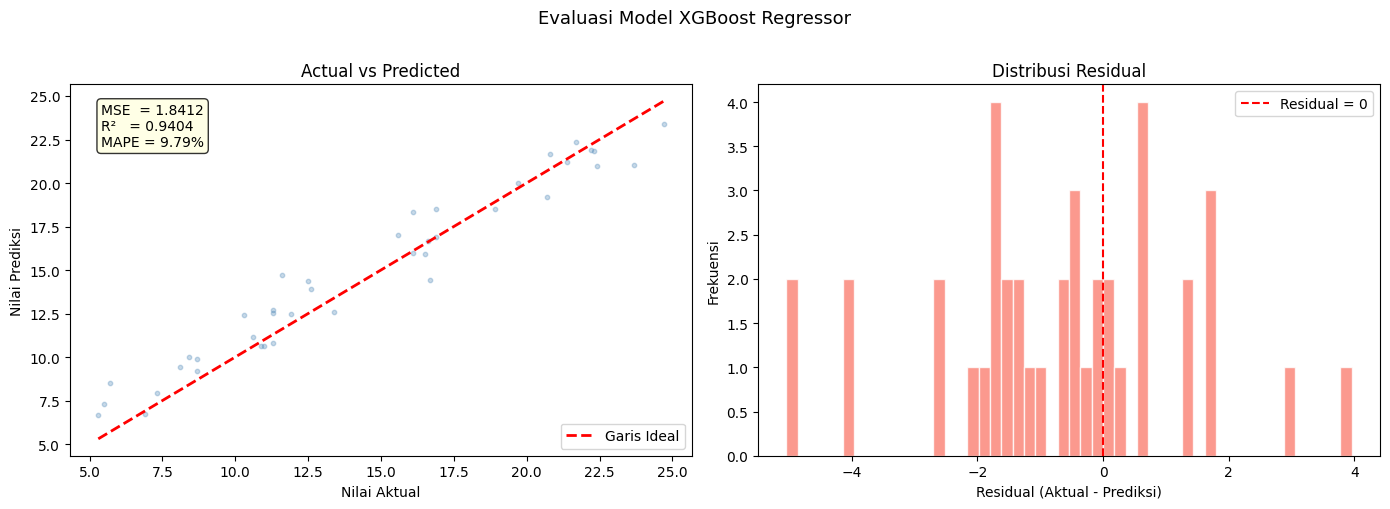

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_xg, alpha=0.3, color='steelblue', s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Garis Ideal'
)
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
# Tambahkan teks metrik
metrik_text = f"MSE  = {mse_xg:.4f}\nR²   = {r2_xg:.4f}\nMAPE = {mape_xg:.2f}%"
axes[0].text(
    0.05, 0.95, metrik_text,
    transform=axes[0].transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
 
# Plot 2: Distribusi Residual
residuals = y_test - y_pred_rf
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
axes[1].set_xlabel('Residual (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
 
plt.suptitle('Evaluasi Model XGBoost Regressor', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()